In [1]:
%pip install earthengine-api xarray rasterio localtileserver geemap pydantic==1.10.21 digitalhub==0.8.1

  Using cached earthengine_api-1.5.5-py3-none-any.whl (459 kB)
  Using cached xarray-2025.1.2-py3-none-any.whl (1.2 MB)
  Using cached rasterio-1.4.3-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (22.2 MB)
  Using cached localtileserver-0.10.6-py3-none-any.whl (17.1 MB)
  Using cached geemap-0.35.2-py2.py3-none-any.whl (2.3 MB)
  Using cached pydantic-1.10.21-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (3.3 MB)
  Using cached google_cloud_storage-3.1.0-py2.py3-none-any.whl (174 kB)
  Using cached google_api_python_client-2.162.0-py2.py3-none-any.whl (13.1 MB)
  Using cached google_auth_httplib2-0.2.0-py2.py3-none-any.whl (9.3 kB)
  Using cached httplib2-0.22.0-py3-none-any.whl (96 kB)
  Using cached packaging-24.2-py3-none-any.whl (65 kB)
  Using cached affine-2.4.0-py3-none-any.whl (15 kB)
  Using cached cligj-0.7.2-py3-none-any.whl (7.1 kB)
  Using cached click_plugins-1.1.1-py2.py3-none-any.whl (7.5 kB)
  Using cached Flask_Caching-2.3.1-py3-none-any.whl 

In [5]:
import os
import digitalhub as dh 

PROJECT_NAME = "flood-detection"
project = dh.get_or_create_project(PROJECT_NAME)

In [6]:
geProject = 'dh-platform-rsde'
before_event_start = '2018-10-05'
before_event_end = '2018-10-26'
after_event_start = '2018-10-27'
after_event_end = '2018-11-20'
aoi_coordinates_str = '10.42,46.29; 11.62,46.29; 11.62,45.73; 10.42,45.73'
s1_collection = 'COPERNICUS/S1_GRD'
s2_collection = 'COPERNICUS/S2_SR'
dem_collection = 'WWF/HydroSHEDS/03VFDEM'
swater_dataset = 'JRC/GSW1_0/GlobalSurfaceWater'
chirps_start_date = '2018-07-01'
chirps_end_date = '2018-11-30'
polarization =  'VV'
pass_direction = 'ASCENDING'
difference_threshold = 1.25

# Graph

In [7]:
precipitaion = project.get_dataitem('precipitation')
data = precipitaion.as_df()

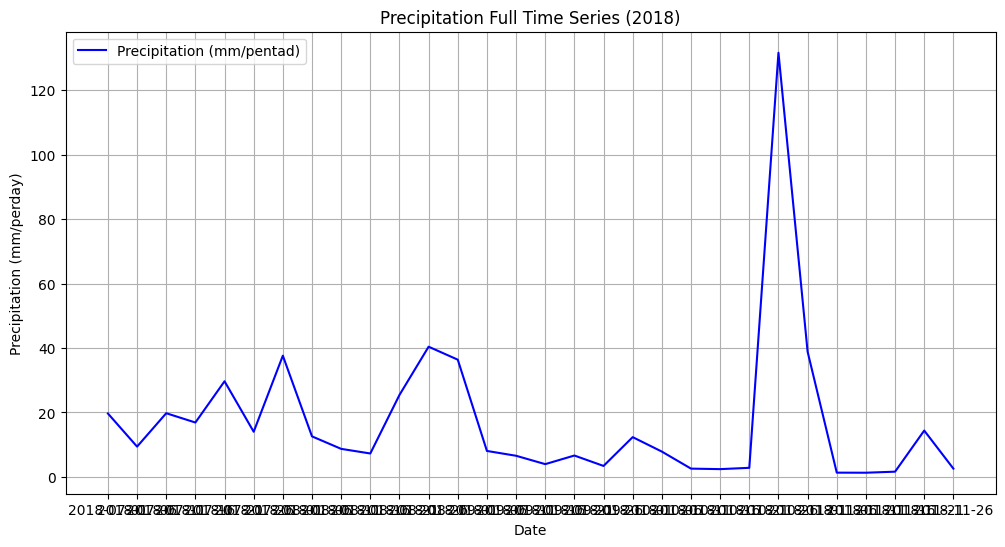

In [8]:
import matplotlib.pyplot as plt

dataP = data.sort_values(by='Date')

# Plot the time series
plt.figure(figsize=(12, 6))
plt.plot(data['Date'], data['Precipitation'], color='blue', label='Precipitation (mm/pentad)')
plt.xlabel('Date')
plt.ylabel('Precipitation (mm/perday)')
plt.title('Precipitation Full Time Series (2018)') #change the title accordingly
plt.legend()
plt.grid(True)
plt.show()

Copy key.json file inside 'data' directory and rename it as key.json(if not already)

In [9]:
import configparser
import ee
import pandas as pd
from os import path, makedirs
from google.auth import compute_engine, impersonated_credentials
import json
    
data_dir='data'
service_account_secret = project.get_secret("service_account")
service_account = service_account_secret.read_secret_value()
private_key_secret = project.get_secret("private_key_json")
private_key_json = private_key_secret.read_secret_value()

with open(data_dir + '/key.json', "w") as outfile:
    outfile.write(private_key_json)
    
credentials = ee.ServiceAccountCredentials(service_account, data_dir + '/key.json')
ee.Initialize(credentials, project=geProject)

In [10]:
import ee 
# Parse the coordinates string into a list of lists for ee.Geometry.Polygon
if aoi_coordinates_str:
    aoi_coordinates = [
        [float(coord.split(',')[0]), float(coord.split(',')[1])]
        for coord in aoi_coordinates_str.split(';')
    ]
else:
    # Default AOI if not specified in config
    aoi_coordinates = [
        [10.42, 46.29],
        [11.62, 46.29],
        [11.62, 45.73],
        [10.42, 45.73]
    ]

# Define AOI (Area of Interest)
aoi = ee.Geometry.Polygon([aoi_coordinates])
print("AOI successfully loaded")

AOI successfully loaded


### Read from Platform S1 Collecton, Swater, DEM

In [ ]:
s1_collection = project.get_artifact('s1_collection_img')
s1collection_img = s1_collection.download(overwrite=True)
s1_image = ee.ImageCollection.load(s1collection_img).filter(ee.Filter.eq('instrumentMode', 'IW')) \
    .filter(ee.Filter.listContains('transmitterReceiverPolarisation', polarization)) \
    .filter(ee.Filter.eq('orbitProperties_pass', pass_direction)) \
    .filter(ee.Filter.eq('resolution_meters', 10)) \
    .filterBounds(aoi) \
    .select(polarization)
s1_image

In [ ]:
swater_dataset = project.get_artifact('swater_dataset')
swater_img = swater_dataset.download(overwrite=True)
swater = ee.Image.load(swater_img).select('seasonality')
swater

In [ ]:
dem_collection = project.get_artifact('dem_collection')
dem_collection_img = dem_collection.download(overwrite=True)
DEM = ee.Image.load(dem_collection_img)
DEM

In [ ]:
s2_collection = project.get_artifact('s2_collection_img')
s2collection_img = s2_collection.download(overwrite=True)
s2_image = ee.ImageCollection.load(s2collection_img).filter(ee.Filter.eq('instrumentMode', 'IW')) \
    .filter(ee.Filter.listContains('transmitterReceiverPolarisation', polarization)) \
    .filter(ee.Filter.eq('orbitProperties_pass', pass_direction)) \
    .filter(ee.Filter.eq('resolution_meters', 10)) \
    .filterBounds(aoi) \
    .select(polarization)
s2_image

In [ ]:
s1_image

In [11]:
import geemap
import ipyleaflet

# READ IT FROM PLATFORM ( # Comment Nawaz-> instead try s1_image loaded from piattaforma )
collection = ee.ImageCollection('COPERNICUS/S1_GRD') \
    .filter(ee.Filter.eq('instrumentMode', 'IW')) \
    .filter(ee.Filter.listContains('transmitterReceiverPolarisation', polarization)) \
    .filter(ee.Filter.eq('orbitProperties_pass', pass_direction)) \
    .filter(ee.Filter.eq('resolution_meters', 10)) \
    .filterBounds(aoi) \
    .select(polarization)

before_collection = collection.filterDate(before_event_start, before_event_end)
after_collection = collection.filterDate(after_event_start, after_event_end)

# Create mosaics and apply focal mean (smoothing)
before = before_collection.mosaic().clip(aoi).focal_mean(50, 'circle', 'meters')
after = after_collection.mosaic().clip(aoi).focal_mean(50, 'circle', 'meters')

# Calculate the difference and apply threshold
difference = after.divide(before)
flood_mask = difference.gt(difference_threshold)

# READ IT FROM PLATFORM
swater = ee.Image.load('JRC/GSW1_0/GlobalSurfaceWater').select('seasonality') # try to comment it to use image from piattaform
swater_mask = swater.gte(10)
flooded = flood_mask.where(swater_mask, 0).updateMask(flood_mask)

connections = flooded.connectedPixelCount(10)
flooded = flooded.updateMask(connections.gte(10))

# READ IT FROM PLATFORM
DEM = ee.Image.load('WWF/HydroSHEDS/03VFDEM') # try to comment it to use image from piattaform
slope = ee.Terrain.slope(DEM)
flooded = flooded.updateMask(slope.lt(7)) #need to change slope values depend on the area

# Add flooded areas to map
print("Flooded areas calculated.")

# Create a map and add Sentinel-1 layers
Map_S1 = geemap.Map(center=[46.0, 11.0], zoom=8)  # Adjust center and zoom level as needed

# Add before and after flood Sentinel-1 layers
Map_S1.addLayer(before, {'min': -25, 'max': 0}, 'S1 - Before Flood')
Map_S1.addLayer(after, {'min': -25, 'max': 0}, 'S1 - After Flood')

# Add Sentinel-1 flood extent layer
Map_S1.addLayer(flooded, {'palette': 'red'}, 'S1 - Flood Extent')

# Add AOI
Map_S1.addLayer(aoi, {}, 'AOI')

# Display the map
Map_S1.addLayerControl()  # Add layer control to toggle layers on/off
Map_S1

Flooded areas calculated.


Map(center=[46.0, 11.0], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI(…

In [ ]:
print(flooded.getInfo())
# geemap.ee_export_image_collection(before, out_dir='./output')
geemap.ee_export_image(
    flooded, filename='tif.tif', scale=90, region=aoi, file_per_band=True
)

In [ ]:
%pip install xarray rasterio localtileserver geemap pydantic==1.10.21 digitalhub==0.8.1

In [ ]:
# Create a map and add Sentinel-1 layers
import geemap 
Map_SS = geemap.Map(center=[46.0, 11.0], zoom=8)  # Adjust center and zoom level as needed
# Map_SS.add_raster('tif.VV.tif', colormap="terrain", layer_name="DEM")
Map_SS.add_raster('cog.tif', colormap="terrain", layer_name="DEM")
Map_SS

In [ ]:
rgb_img = geemap.ee_to_numpy(swater, region=aoi)
cog = geemap.numpy_to_cog(rgb_img, "cog.tif")
print(rgb_img.shape)

In [12]:
def mask_clouds(image):
    qa = image.select('QA60')  # Sentinel-2 QA60 band for clouds
    cloud_mask = qa.bitwiseAnd(1 << 10).eq(0).And(qa.bitwiseAnd(1 << 11).eq(0))
    return image.updateMask(cloud_mask)

def calculate_ndwi(image):
    ndwi = image.normalizedDifference(['B3', 'B8']).rename('NDWI')
    return ndwi.updateMask(ndwi).clip(aoi)


In [13]:
# READ IT FROM PLATFORM

# Define Sentinel-2 functions
# Load Sentinel-2 collection and apply cloud masking
# Comment Nawaz-> instead try s2_image
sentinel2 = (ee.ImageCollection('COPERNICUS/S2_SR')
    .filterBounds(aoi)
    .filterDate(before_event_start, after_event_end)
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 50))  # Increased threshold from 20 to 50
    .map(mask_clouds)  # Apply cloud and shadow masking
)

# Calculate NDWI for before and after periods
s2_before_collection = sentinel2.filterDate(before_event_start, before_event_end).map(calculate_ndwi)
s2_after_collection = sentinel2.filterDate(after_event_start, after_event_end).map(calculate_ndwi)

# Calculate NDWI for before and after periods
s2_before_collection = sentinel2.filterDate(before_event_start, before_event_end).map(calculate_ndwi)
s2_after_collection = sentinel2.filterDate(after_event_start, after_event_end).map(calculate_ndwi)

s2_before = s2_before_collection.median()
s2_after = s2_after_collection.median()

# Check if both collections have valid data
if s2_before_collection.size().getInfo() > 0 and s2_after_collection.size().getInfo() > 0:
    # Create median composites
    s2_before = s2_before_collection.median()
    s2_after = s2_after_collection.median()
    # Calculate flood extent based on NDWI difference
    s2_flood = s2_after.subtract(s2_before).gt(0.1).rename('Flood')
    # Mask permanent water bodies
    ## Comment Nawaz-> try to use the image 'swater_img' from platform
    permanent_water = ee.Image('JRC/GSW1_0/GlobalSurfaceWater').select('seasonality').gte(10)
    s2_flood = s2_flood.where(permanent_water, 0)
    # Apply mask to Sentinel-2 flood results
    s2_flood = s2_flood.updateMask(permanent_water.Not())
else:
    print("No valid Sentinel-2 data available for the specified periods.")

In [14]:
import geemap

# Initialize a geemap Map object centered on the AOI
Map_S2 = geemap.Map(center=[45.95, 11.02], zoom=8)  # Adjust center to your AOI

# Check if both collections have valid data and visualize
if s2_before_collection.size().getInfo() > 0 and s2_after_collection.size().getInfo() > 0:
    # Add NDWI layers for before and after flood
    Map_S2.addLayer(s2_before, {'min': -0.2, 'max': 0.5, 'palette': ['white', 'blue']}, 'S2 - Before Flood (NDWI)')
    Map_S2.addLayer(s2_after, {'min': -0.2, 'max': 0.5, 'palette': ['white', 'blue']}, 'S2 - After Flood (NDWI)')

    # Add flood extent layer
    Map_S2.addLayer(s2_flood, {'palette': 'red'}, 'S2 - Flood Extent')

    # Add AOI for reference
    Map_S2.addLayer(aoi, {}, 'AOI')
else:
    print("No valid Sentinel-2 data available for visualization.")

# Display the map
Map_S2.addLayerControl()  # Add layer controls
Map_S2

Map(center=[45.95, 11.02], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGU…